# Practice 1: PyTorch FashionMNIST Classification

## MLP vs DiagnosticCNN — Comparison

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Import Libraries | Load PyTorch, src modules, detect device | — |
| 2 | Load Dataset | Download FashionMNIST, create or load persistent train/val/test split | `src/data_utils.py` |
| 3 | Explore Dataset | Shape, class distribution, pixel stats | `src/vis_utils.py` |
| 4 | Define Models | MLP (Linear) vs DiagnosticCNN (Conv, BN, GAP) | — |
| 5 | Train Both Models | MLP: 30ep AdamW+CosLR+early stop; CNN: 35ep AdamW+CosLR+early stop | `src/train_utils.py` |
| 6 | Compare: Loss Curves | Train + test loss curves, solid/dashed for overfitting check | `src/vis_utils.py` |
| 7 | Compare: Confusion Matrices | Per-class TPR/FPR/Precision + heatmaps | `src/eval_utils.py` |
| 8 | Compare: ROC Curves | Per-class ROC curves + AUC scores | `src/eval_utils.py` + `src/vis_utils.py` |
| 9 | Compare: PR Curves | Per-class Precision-Recall curves + AP | `src/eval_utils.py` + `src/vis_utils.py` |
| 10 | Summary Table | Accuracy / ROC-AUC / PR-AUC / Params side-by-side | `src/eval_utils.py` |
| 11 | Save Models | Save .pth weights to `outputs/practice_1/model/` | `src/model_utils.py` |
| 12 | Display Predictions | Predicted vs actual images for MLP + CNN | `src/vis_utils.py` |

---





## 1. Import Libraries

Import `src/` utility modules, PyTorch core, and auto-detect device (MPS > CUDA > CPU).

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
import copy

from src.data_utils import load_subsets, create_full_split
from src.vis_utils import explore_dataset, plot_losses, plot_confusion_matrix
from src.vis_utils import plot_roc_curves, plot_pr_curves, plot_predictions
from src.model_utils import save_model
from src.train_utils import train_model
from src.eval_utils import evaluate_detailed, get_all_probas_and_labels
from src.eval_utils import compute_roc_auc_scores, compute_pr_auc_scores, print_comparison_table

print(f"PyTorch version: {torch.__version__}")
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.13.0+cu130
Using device: cuda


## 2. Load Dataset & DataLoaders

The full 70k FashionMNIST dataset is split into **train (50k) / val (6k) / test (14k)**.  
The split is **created once** and saved to `splits/train_indices.json`, `splits/val_indices.json`, `splits/test_indices.json`.  
Every subsequent run loads these files directly — the split is deterministic, replayable, and identical across machines.

In [2]:
create_full_split(train_size=50000, val_size=6000, test_size=14000, split_dir='../splits', root='../data')
train_loader, val_loader, test_loader, class_names = load_subsets(
    batch_size=64, val_batch_size=256, split_dir='../splits', root='../data')

train_size = len(train_loader.dataset)
val_size = len(val_loader.dataset)
test_size = len(test_loader.dataset)
print(f'Train: {train_size}  Val: {val_size}  Test: {test_size}')

[data_utils] Split created: train=50000, val=6000, test=14000
[data_utils] Saved to ..\splits/
Train: 50000  Val: 6000  Test: 14000


## 3. Explore Dataset

Print basic info (classes, shape), show 10 sample images, class distribution bar chart, and pixel intensity histogram.

In [3]:
sample_loader = DataLoader(train_loader.dataset, batch_size=1, shuffle=True)
sample_img, _ = next(iter(sample_loader))
print(f'Image shape: {sample_img.shape}')
print(f'Number of classes: {len(class_names)}')
print(f'Classes: {class_names}')

Image shape: torch.Size([1, 1, 28, 28])
Number of classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 4. Define Models

**MLP:** `784 -> 215 -> 470 -> 10`, GELU, Dropout(0.05).
Best HPs from Optuna (Exp 4, 50 trials, TPE + Median pruner): AdamW, lr=0.002, wd=2e-6, CosineAnnealingLR, 30 epochs.

**DiagnosticCNN:** 3 conv blocks (32→64→128), BatchNorm, ReLU, MaxPool, GAP, Dropout(0.454).
Best HPs from Optuna (Exp 12): AdamW, lr=0.003322, weight_decay=1.39e-5, CosineAnnealingLR, 35 epochs.

In [4]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_1=256, hidden_2=128, num_classes=10, dropout=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, num_classes)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = self.act(self.fc1(x))
        x = self.dropout(x)
        x = self.act(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


class DiagnosticCNN(nn.Module):
    def __init__(self, dropout=0.454):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.net(x)


model_mlp = MLP(hidden_1=215, hidden_2=470, dropout=0.05).to(device)
model_cnn = DiagnosticCNN().to(device)

mlp_params = sum(p.numel() for p in model_mlp.parameters())
cnn_params = sum(p.numel() for p in model_cnn.parameters())
print(f'MLP params: {mlp_params:,}')
print(f'CNN params: {cnn_params:,}')
# DiagnosticCNN has ~134k params — significantly more than the baseline 2-conv CNN (~50k)

MLP params: 275,005
CNN params: 140,778


c:\document\Study documents\Deeplearning_Course\.venv\Lib\site-packages\torch\nn\modules\module.py:1369: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  return t.to(


## 5. Train Both Models

MLP: `CrossEntropyLoss`, `AdamW(lr=0.002, weight_decay=2e-6)`, `CosineAnnealingLR(T_max=30)`, patience=5 early stopping.
Best HPs from Optuna (Exp 4, 50 trials, TPE + Median pruner).

**DiagnosticCNN:** AdamW(lr=0.003322, weight_decay=1.39e-5), CosineAnnealingLR(T_max=35), 35 epochs.
Best HPs from Optuna Bayesian search (Exp 12, 30 trials × 35 epochs, ASHA pruning).

In [5]:
criterion = nn.CrossEntropyLoss()

print('--- Training MLP ---')
from src.train_utils import train_one_epoch
optimizer_mlp = optim.AdamW(model_mlp.parameters(), lr=0.002, weight_decay=2e-6)
scheduler_mlp = CosineAnnealingLR(optimizer_mlp, T_max=30)
train_losses_mlp = []
val_losses_mlp = []
best_val_loss = float('inf')
best_mlp_state = None
patience = 5
wait = 0
model_mlp.train()
for epoch in range(30):
    train_loss = train_one_epoch(model_mlp, train_loader, criterion, optimizer_mlp, device)
    train_losses_mlp.append(train_loss)
    scheduler_mlp.step()

    model_mlp.eval()
    vloss = 0.0
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            vloss += criterion(model_mlp(img), lbl).item()
    val_losses_mlp.append(vloss / len(val_loader))
    model_mlp.train()

    if val_losses_mlp[-1] < best_val_loss:
        best_val_loss = val_losses_mlp[-1]
        best_mlp_state = copy.deepcopy(model_mlp.state_dict())
        wait = 0
    else:
        wait += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/30]  Train: {train_loss:.4f}  Val: {val_losses_mlp[-1]:.4f}')
    
    if wait >= patience:
        print(f'Early stop at epoch {epoch+1} (no val improvement for {patience} epochs)')
        break

model_mlp.load_state_dict(best_mlp_state)
print(f'Restored best MLP checkpoint (val_loss={best_val_loss:.4f})')
import os
os.makedirs('../outputs/practice_1/metrics', exist_ok=True)
with open('../outputs/practice_1/metrics/train_losses_MLP.txt', 'w') as f:
    for loss in train_losses_mlp:
        f.write(f'{loss}\n')
with open('../outputs/practice_1/metrics/val_losses_MLP.txt', 'w') as f:
    for loss in val_losses_mlp:
        f.write(f'{loss}\n')

print('\n--- Training DiagnosticCNN ---')
EPOCHS_CNN = 35
optimizer_cnn = optim.AdamW(model_cnn.parameters(), lr=0.003322, weight_decay=1.39e-5)
scheduler_cnn = CosineAnnealingLR(optimizer_cnn, T_max=EPOCHS_CNN)
train_losses_cnn = []
val_losses_cnn = []
best_val_loss_cnn = float('inf')
best_cnn_state = None
wait_cnn = 0
model_cnn.train()
for epoch in range(EPOCHS_CNN):
    train_loss = train_one_epoch(model_cnn, train_loader, criterion, optimizer_cnn, device)
    train_losses_cnn.append(train_loss)
    scheduler_cnn.step()

    model_cnn.eval()
    vloss = 0.0
    with torch.no_grad():
        for img, lbl in val_loader:
            img, lbl = img.to(device), lbl.to(device)
            vloss += criterion(model_cnn(img), lbl).item()
    val_losses_cnn.append(vloss / len(val_loader))
    model_cnn.train()

    if val_losses_cnn[-1] < best_val_loss_cnn:
        best_val_loss_cnn = val_losses_cnn[-1]
        best_cnn_state = copy.deepcopy(model_cnn.state_dict())
        wait_cnn = 0
    else:
        wait_cnn += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS_CNN}]  Train: {train_loss:.4f}  Val: {val_losses_cnn[-1]:.4f}')
    
    if wait_cnn >= patience:
        print(f'Early stop at epoch {epoch+1} (no val improvement for {patience} epochs)')
        break

model_cnn.load_state_dict(best_cnn_state)
print(f'Restored best CNN checkpoint (val_loss={best_val_loss_cnn:.4f})')
os.makedirs('../outputs/practice_1/metrics', exist_ok=True)
with open('../outputs/practice_1/metrics/train_losses_CNN.txt', 'w') as f:
    for loss in train_losses_cnn:
        f.write(f'{loss}\n')
with open('../outputs/practice_1/metrics/val_losses_CNN.txt', 'w') as f:
    for loss in val_losses_cnn:
        f.write(f'{loss}\n')

--- Training MLP ---
Epoch [1/30]  Train: 0.5091  Val: 0.4495
Epoch [5/30]  Train: 0.3219  Val: 0.3780
Epoch [10/30]  Train: 0.2517  Val: 0.3434
Epoch [15/30]  Train: 0.1858  Val: 0.3690
Early stop at epoch 15 (no val improvement for 5 epochs)
Restored best MLP checkpoint (val_loss=0.3434)

--- Training DiagnosticCNN ---
Epoch [1/35]  Train: 0.5161  Val: 0.3740
Epoch [5/35]  Train: 0.2249  Val: 0.2288
Epoch [10/35]  Train: 0.1523  Val: 0.2150
Epoch [15/35]  Train: 0.0953  Val: 0.2211
Early stop at epoch 16 (no val improvement for 5 epochs)
Restored best CNN checkpoint (val_loss=0.1968)


## 6. Compare: Loss Curves

Solid lines = training loss, dashed lines = test loss (with marker shapes).
Train/test divergence signals overfitting; both decreasing together signals good generalization.

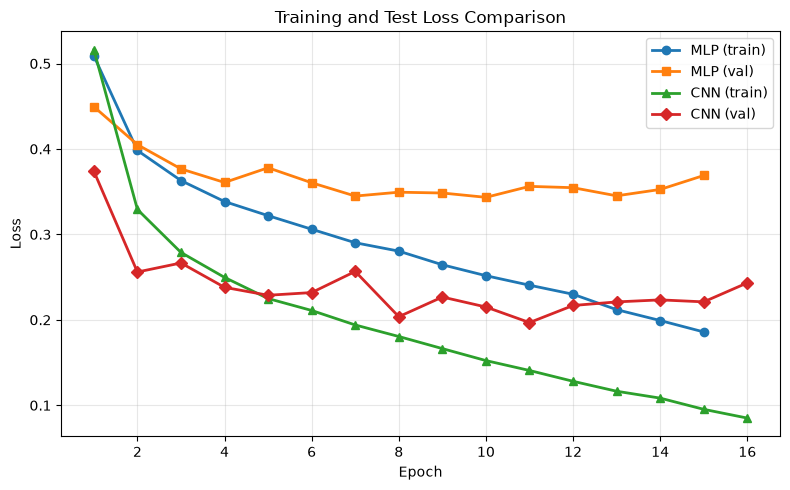

In [6]:
plot_losses({
    'MLP (train)': train_losses_mlp,
    'MLP (val)': val_losses_mlp,
    'CNN (train)': train_losses_cnn,
    'CNN (val)': val_losses_cnn,
}, title='Training and Test Loss Comparison',
   save_path='../outputs/practice_1/plots/train_val_losses.png')

## 7. Compare: Confusion Matrices

Print accuracy, TPR (Recall), FPR, Precision per class + confusion matrix heatmaps for both models.

  Test Accuracy: 88.45%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8940     0.0269     0.7887
  Trouser             0.9801     0.0012     0.9892
  Pullover            0.8028     0.0155     0.8496
  Dress               0.9037     0.0147     0.8703
  Coat                0.8025     0.0184     0.8244
  Sandal              0.9606     0.0083     0.9304
  Shirt               0.6750     0.0277     0.7356
  Sneaker             0.9173     0.0060     0.9449
  Bag                 0.9649     0.0041     0.9643
  Ankle boot          0.9430     0.0056     0.9472


  Test Accuracy: 93.30%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.9004     0.0141     0.8780
  Trouser             0.9929     0.0008     0.9929
  Pullover            0.9355     0.0162     0.8635
  Dress               0.9196     0.0075     0.9304
  Coat                0.8924     0.0

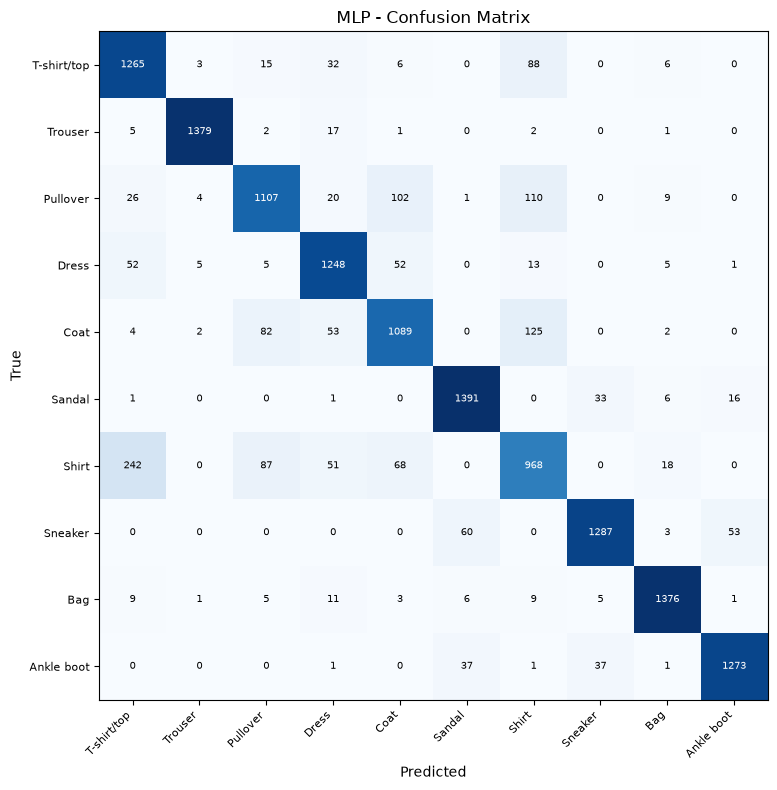

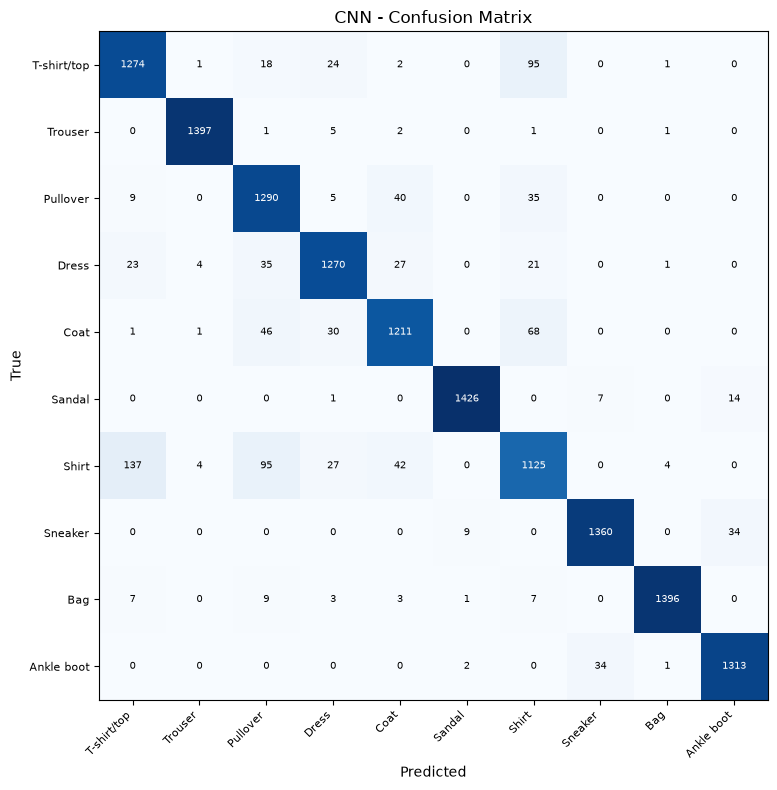

In [7]:
acc_mlp, cm_mlp, _ = evaluate_detailed(model_mlp, test_loader, device, class_names, model_name='MLP')
print('\n')
acc_cnn, cm_cnn, _ = evaluate_detailed(model_cnn, test_loader, device, class_names, model_name='CNN')

plot_confusion_matrix(cm_mlp, class_names, title='MLP - Confusion Matrix',
                      save_path='../outputs/practice_1/plots/confusion_matrix_mlp.png')
plot_confusion_matrix(cm_cnn, class_names, title='CNN - Confusion Matrix',
                      save_path='../outputs/practice_1/plots/confusion_matrix_cnn.png')

## 8. Compare: ROC Curves

Per-class ROC curves (10 subplots), each showing MLP vs CNN with AUC values. Macro AUC printed to console.

MLP macro ROC-AUC: 0.9913
CNN macro ROC-AUC: 0.9966


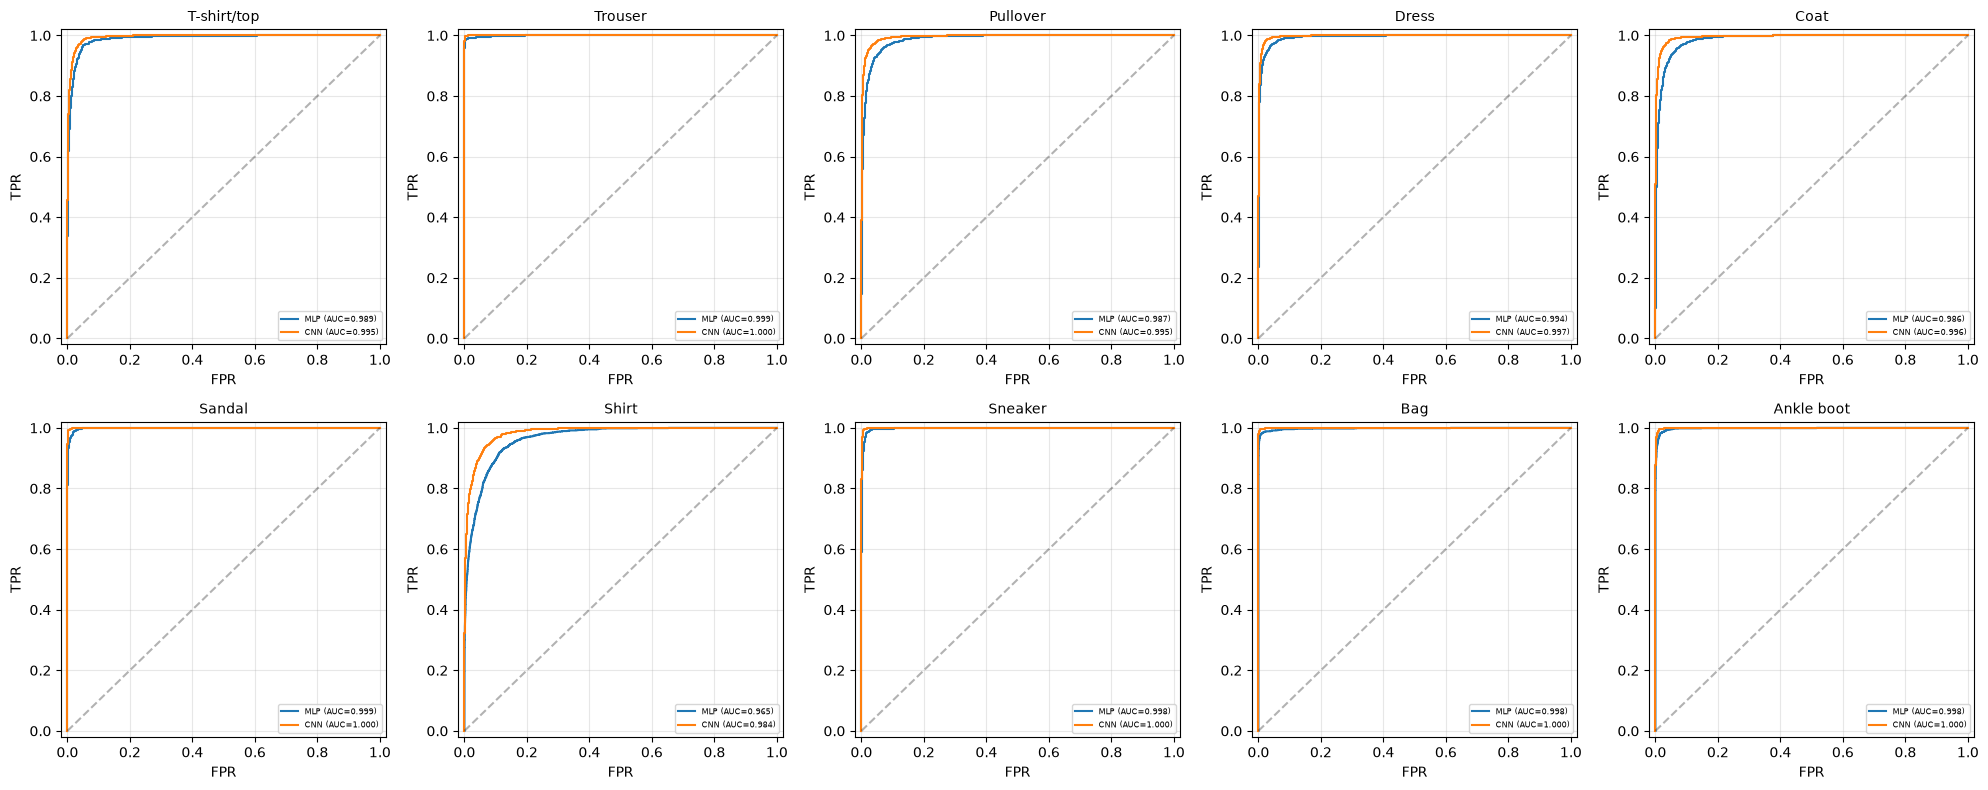

In [8]:
probas_mlp, labels = get_all_probas_and_labels(model_mlp, test_loader, device, 10)
probas_cnn, _ = get_all_probas_and_labels(model_cnn, test_loader, device, 10)

roc_mlp = compute_roc_auc_scores(probas_mlp, labels, model_name='MLP')
roc_cnn = compute_roc_auc_scores(probas_cnn, labels, model_name='CNN')

print(f'MLP macro ROC-AUC: {roc_mlp["macro"]:.4f}')
print(f'CNN macro ROC-AUC: {roc_cnn["macro"]:.4f}')

plot_roc_curves({'MLP': probas_mlp, 'CNN': probas_cnn}, labels, class_names)

## 9. Compare: PR Curves

Per-class Precision-Recall curves (10 subplots), MLP vs CNN with AP (Average Precision) values.

MLP macro PR-AUC (AP): 0.9431
CNN macro PR-AUC (AP): 0.9761


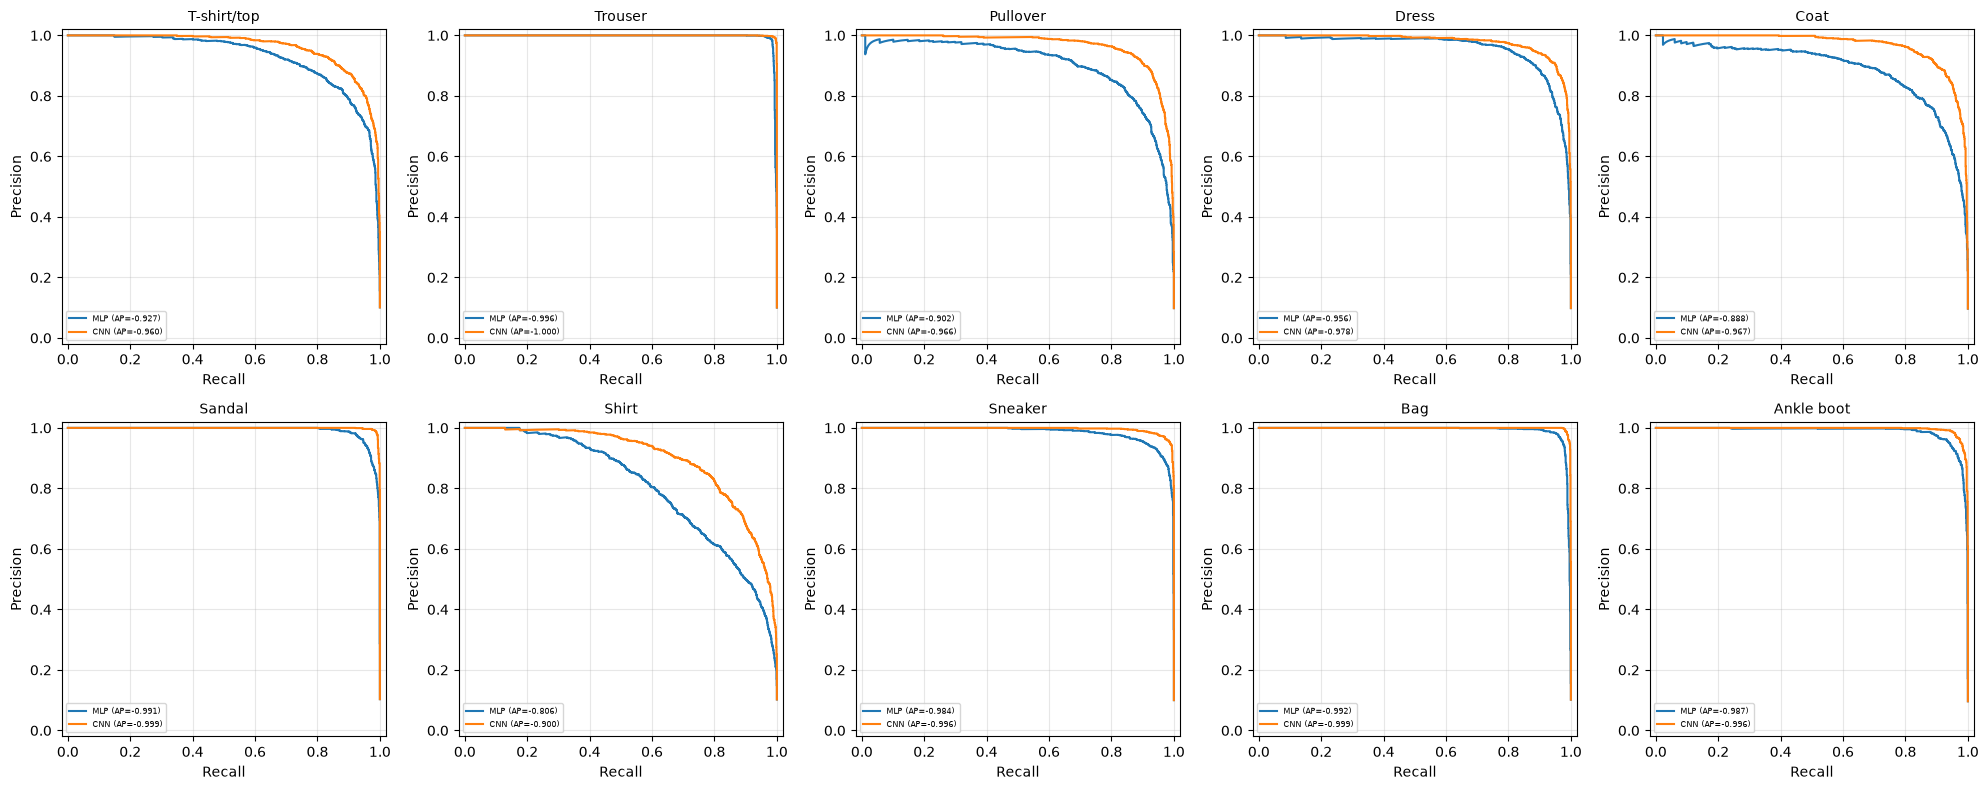

In [9]:
pr_mlp = compute_pr_auc_scores(probas_mlp, labels, model_name='MLP')
pr_cnn = compute_pr_auc_scores(probas_cnn, labels, model_name='CNN')

print(f'MLP macro PR-AUC (AP): {pr_mlp["macro"]:.4f}')
print(f'CNN macro PR-AUC (AP): {pr_cnn["macro"]:.4f}')

plot_pr_curves({'MLP': probas_mlp, 'CNN': probas_cnn}, labels, class_names)

## 10. Summary Table

Compare Accuracy, ROC-AUC, PR-AUC (macro), and parameter count side-by-side, plus per-class breakdown.

In [10]:
print_comparison_table(acc_mlp, acc_cnn, roc_mlp, roc_cnn, pr_mlp, pr_cnn,
                       mlp_params, cnn_params, class_names)

Metric                             MLP          CNN         Diff
---------------------------------------------------------------------------
Test Accuracy (%)               88.45       93.30       +4.85
Macro ROC-AUC                  0.9913      0.9966     +0.0053
Macro PR-AUC (AP)              0.9431      0.9761     +0.0330
Parameters                    275,005     140,778    -134,227

Per-class ROC-AUC                  MLP          CNN
--------------------------------------------------
T-shirt/top                    0.9893      0.9948
Trouser                        0.9992      1.0000
Pullover                       0.9865      0.9953
Dress                          0.9941      0.9974
Coat                           0.9861      0.9955
Sandal                         0.9988      0.9999
Shirt                          0.9647      0.9842
Sneaker                        0.9980      0.9996
Bag                            0.9981      0.9998
Ankle boot                     0.9982      0.9996

Per-cl

## 11. Save Models

Save `.pth` weights to `outputs/model/` for future inference without retraining.

In [11]:
save_model(model_mlp, '../outputs/practice_1/model/mlp_fashion_mnist.pth')
save_model(model_cnn, '../outputs/practice_1/model/cnn_fashion_mnist.pth')

Model saved to ../outputs/practice_1/model/mlp_fashion_mnist.pth
Model saved to ../outputs/practice_1/model/cnn_fashion_mnist.pth


## 12. Display Predicted vs Actual Images

First batch of test set: green = correct, red = wrong. MLP and CNN side-by-side.

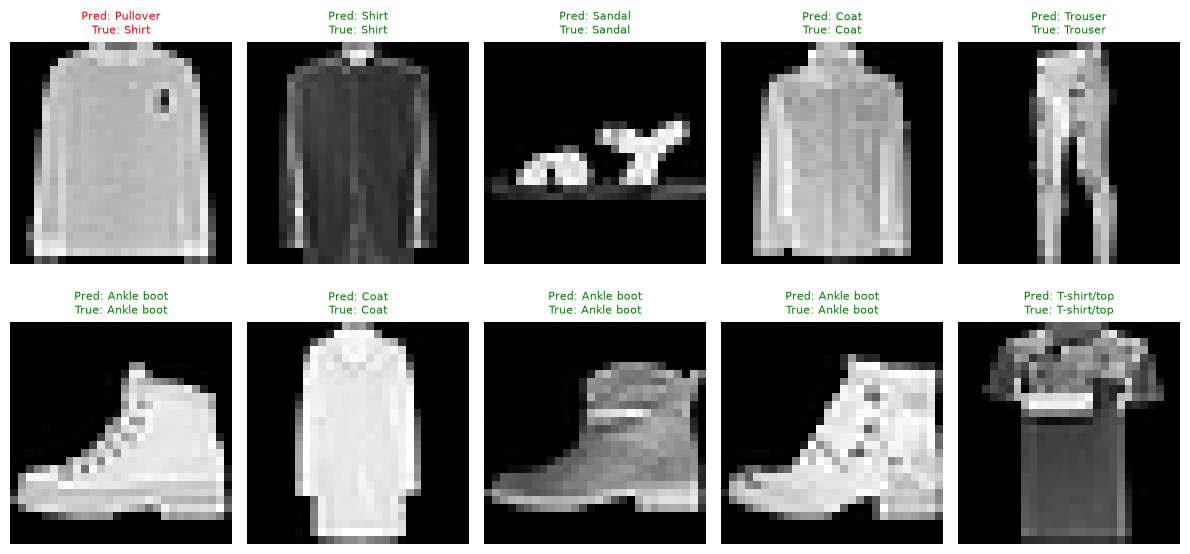

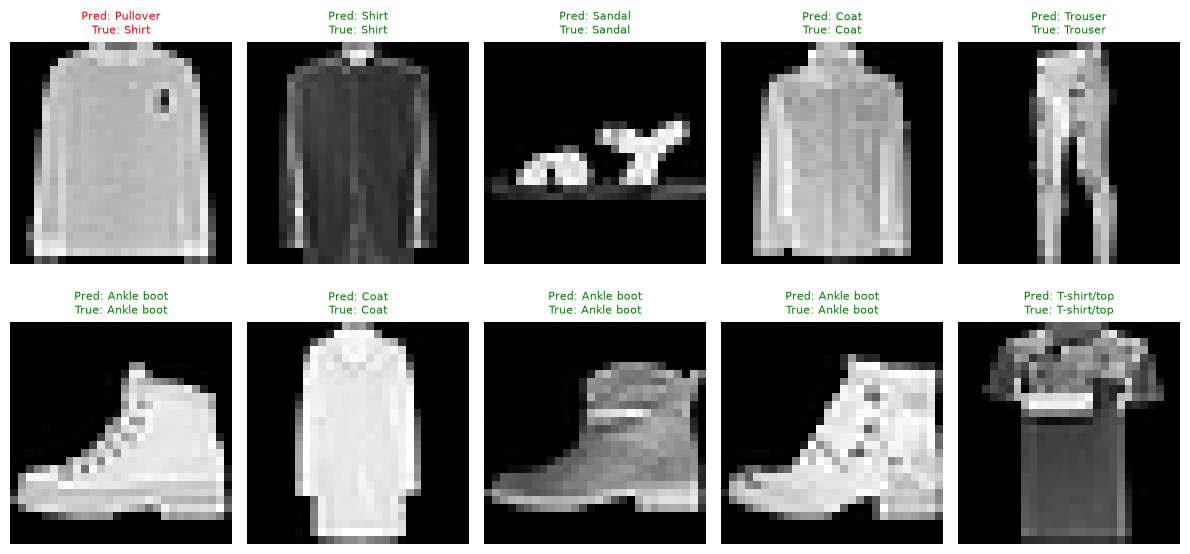

In [12]:
plot_predictions(model_mlp, test_loader, class_names, device,
               '../outputs/practice_1/plots/predictions_mlp.png')
plot_predictions(model_cnn, test_loader, class_names, device,
               '../outputs/practice_1/plots/predictions_cnn.png')